<a href="https://colab.research.google.com/github/Jerynnn/Jerynnn/blob/main/.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error


np.random.seed(42)
X = np.random.uniform(0, 100, 1000).reshape(-1, 1)
y = np.sin(X / 10).ravel() + np.random.normal(0, 0.2, 1000)

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

print("Дані згенеровано та нормалізовано. Кількість записів:", len(X_normalized))

Дані згенеровано та нормалізовано. Кількість записів: 1000


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print(f"Навчальна вибірка: {len(X_train)} значень")
print(f"Тестова вибірка: {len(X_test)} значень")

Навчальна вибірка: 800 значень
Тестова вибірка: 200 значень


In [3]:
k_values = range(1, 51)
mse_results = []

best_k = 1
best_mse = float('inf')

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mse_results.append(mse)

    if mse < best_mse:
        best_mse = mse
        best_k = k

print(f"Найкраще значення K: {best_k}")
print(f"Мінімальна похибка (MSE): {best_mse:.4f}")

Найкраще значення K: 22
Мінімальна похибка (MSE): 0.0366


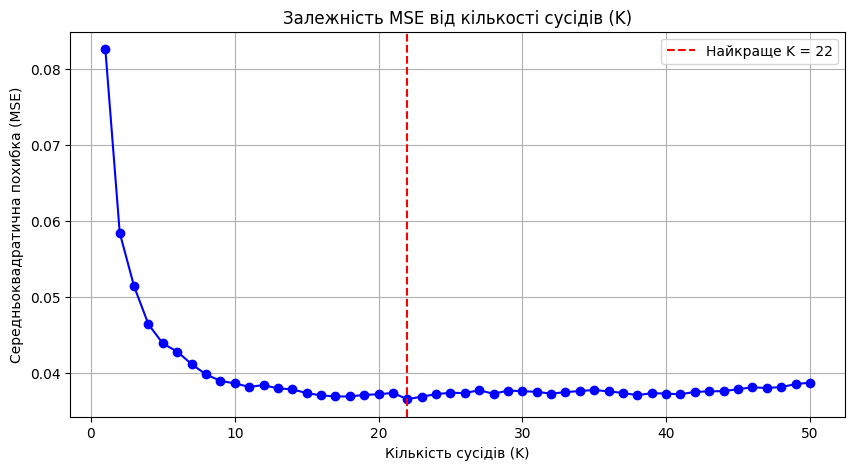

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, mse_results, marker='o', linestyle='-', color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Найкраще K = {best_k}')
plt.title('Залежність MSE від кількості сусідів (K)')
plt.xlabel('Кількість сусідів (K)')
plt.ylabel('Середньоквадратична похибка (MSE)')
plt.legend()
plt.grid(True)
plt.show()

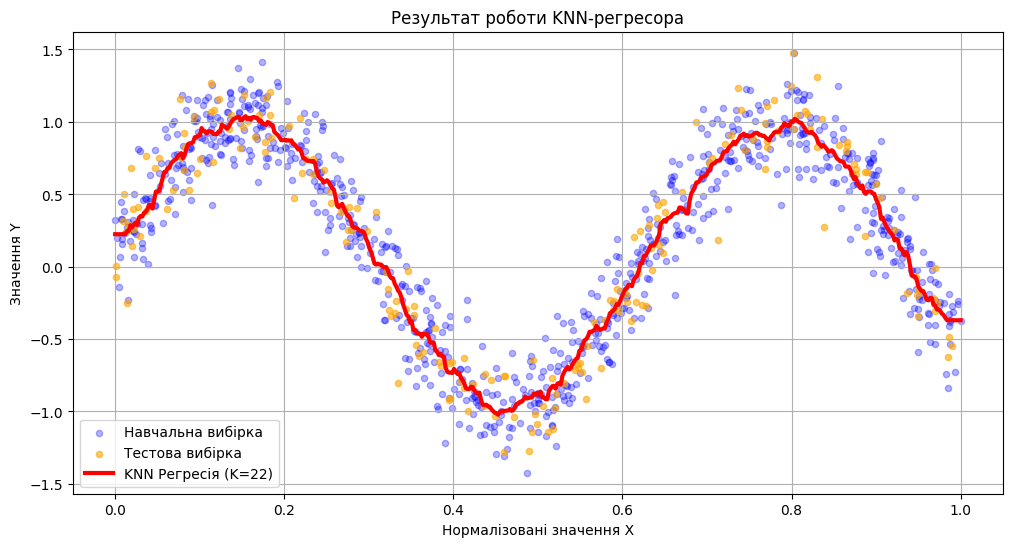

In [5]:
final_knn = KNeighborsRegressor(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

X_plot = np.linspace(0, 1, 500).reshape(-1, 1)
y_plot_pred = final_knn.predict(X_plot)

plt.figure(figsize=(12, 6))

plt.scatter(X_train, y_train, color='blue', alpha=0.3, label='Навчальна вибірка', s=20)
plt.scatter(X_test, y_test, color='orange', alpha=0.6, label='Тестова вибірка', s=20)

plt.plot(X_plot, y_plot_pred, color='red', linewidth=3, label=f'KNN Регресія (K={best_k})')

plt.title('Результат роботи KNN-регресора')
plt.xlabel('Нормалізовані значення X')
plt.ylabel('Значення Y')
plt.legend()
plt.grid(True)
plt.show()